# Divided Temporal Attention

This notebook implements the Divided Temporal Attention mechanism for video data, which is designed to capture temporal dependencies in video sequences while maintaining computational efficiency.

##### Import libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import os
import sys
import h5py
import timm
import torch
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchaudio.transforms as transforms
from torch.utils.data import Dataset, DataLoader

curr_dir = os.getcwd()
root_dir = os.path.dirname(curr_dir)
data_dir = os.path.join(root_dir, 'data')

if root_dir not in sys.path:
	sys.path.append(root_dir)

import aceverify

# Setting HuggingFace token for accessing pretrained models faster
os.environ['HF_HOME'] = os.path.join(root_dir, 'huggingface')
os.environ['HF_TOKEN'] = "" # TODO: Update with your HuggingFace token

Configure Logging in Aceverify module

In [2]:
def configure_logging(logger: logging.Logger, log_level: str = "INFO", force: bool = False):
    numeric_level = getattr(logging, log_level.upper(), logging.INFO)
    logging.basicConfig(
        level=numeric_level,
        format="%(asctime)s | %(levelname)s | %(filename)s:%(lineno)d | %(funcName)s | %(message)s",
        force=force,
    )
    logging.getLogger().setLevel(numeric_level)
    logger.setLevel(numeric_level)

logger = logging.getLogger(__name__)
configure_logging(logger)

##### Temporal Shift Modules (TSM)
TSM is a "zero-parameter, zero-FLOP" technique that moves a fraction of channels along the time dimension to facilitate temporal exchange within a 2D backbone

In [ ]:
class TSM_Model(aceverify.ACEVerifyModel):
    def __init__(self, n_segment=16):
        super().__init__()
        self.n_segment = n_segment

    def tsm_shift(self, x):
        BT, N, C = x.shape
        B, T = BT // self.n_segment, self.n_segment
        x = x.view(B, T, N, C)
        out = torch.zeros_like(x)
        fold = C // 8
        out[:, :-1, :, :fold] = x[:, 1:, :, :fold]      # Shift Forward
        out[:, 1:, :, fold:2*fold] = x[:, :-1, :, fold:2*fold]  # Shift Backward
        out[:, :, :, 2*fold:] = x[:, :, :, 2*fold:]    # Identity
        return out.view(BT, N, C)

    def forward(self, video, specs):
        B, C, T, H, W = video.shape
        frames = video.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)

        # embed patches, then apply TSM on the token stream
        x = self.video_model.patch_embed(frames)  # [B*T, N, 768]
        x = self.tsm_shift(x)                     # [B*T, N, 768]

        # manually continue the ViT pipeline without using forward_features
        x = self.video_model._pos_embed(x)
        x = self.video_model.patch_drop(x)
        x = self.video_model.norm_pre(x)
        x = self.video_model.blocks(x)
        x = self.video_model.norm(x)

        # extract CLS token per frame, then temporal aggregation
        v_feat = x[:, 0, :].reshape(B, T, -1)    # [B, T, 768]
        gru_out, _ = self.temporal_layer(v_feat)
        return self.full_model(self.video_norm(gru_out[:, -1, :]))

##### Temporal Difference Layer
This layer feeds the difference between frames ($f_{t} - f_{t-1}$) into a second GRU and fuse the outputs.

In [4]:
class TempDiffModel(aceverify.ACEVerifyModel):
    def __init__(self):
        super().__init__()
        self.diff_gru = nn.GRU(768, 256, batch_first=True, bidirectional=True)
        self.fusion = nn.Linear(1024 + 512, 1024)

    def forward(self, video, specs):
        B, C, T, H, W = video.shape
        v_feat = self.video_model(video.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)).reshape(B, T, 768)
        
        # Original Stream
        gru_out, _ = self.temporal_layer(v_feat)
        
        # Difference Stream: f(t) - f(t-1)
        diff_feat = v_feat[:, 1:, :] - v_feat[:, :-1, :] 
        diff_out, _ = self.diff_gru(diff_feat)
        
        # Concat and Fuse
        combined = torch.cat([gru_out[:, -1, :], diff_out[:, -1, :]], dim=1)
        video_combined = self.video_norm(self.fusion(combined))
        return self.full_model(video_combined)

##### Divided Attention with Patch Merging

This technique reduces the number of tokens as the data flows deeper into the model, effectively "summarizing" spatial info into higher-dimensional embeddings.

In [ ]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, dim)

    def forward(self, x, H, W):
        BT, L, C = x.shape
        x = x.view(BT, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0, x1, x2, x3], dim=-1)
        x = x.view(BT, -1, 4 * C)
        x = self.norm(x)
        return self.reduction(x)

class DividedAttentionModel(aceverify.ACEVerifyModel):
    def __init__(self):
        super().__init__()
        self.patch_merge = PatchMerging(self.video_model.embed_dim)
        # Unfreezing all blocks so PatchMerging output can be learned end-to-end
        for param in self.video_model.blocks.parameters():
            param.requires_grad = True

    def forward(self, video, specs):
        B, C, T, H, W = video.shape
        frames = video.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)

        x = self.video_model.patch_embed(frames)   # [B*T, 196, 768]
        x = self.patch_merge(x, 14, 14)            # [B*T, 49, 768]

        cls_token = self.video_model.cls_token.expand(x.shape[0], -1, -1)

        # Using timm's resampler for handling interpolation
        pos_embed = timm.layers.resample_abs_pos_embed(
            self.video_model.pos_embed,
            new_size=(7, 7),
            old_size=(14, 14),
        )  # [1, 50, 768]

        x = torch.cat([cls_token, x], dim=1)  # [B*T, 50, 768]
        x = x + pos_embed

        x = self.video_model.norm_pre(x)
        x = self.video_model.blocks(x)
        x = self.video_model.norm(x)

        v_feat = x[:, 0, :].reshape(B, T, -1)     # [B, T, 768]
        gru_out, _ = self.temporal_layer(v_feat)
        return self.full_model(self.video_norm(gru_out[:, -1, :]))

- NOTE: The above implementation yeilded the worst performance amongst all (~50% test & train accuracies which are worse than baseline itself). We hypothesize that the aggressive token merging leads to loss of spatial information from ViT, which is crucial for deepfake detection. Future work would explore more sophisticated token merging strategies or hybrid attention mechanisms to mitigate this issue. 

Without Patch Merging

In [ ]:
class DividedAttentionModel(aceverify.ACEVerifyModel):
    def __init__(self):
        super().__init__()
        # Adding cross-frame attention on top of GRU output
        self.frame_attn = nn.MultiheadAttention(
            embed_dim=1024, num_heads=8, dropout=0.1, batch_first=True
        )
        self.attn_norm = nn.LayerNorm(1024)

    def forward(self, video, specs):
        B, C, T, H, W = video.shape
        frames = video.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)

        # Keeping the ViT completely intact
        v_feat = self.video_model(frames).reshape(B, T, 768)

        # GRU for temporal sequence
        gru_out, _ = self.temporal_layer(v_feat)  # [B, T, 1024]

        # Cross-frame attention on top of GRU for "divided attention"
        attn_out, _ = self.frame_attn(gru_out, gru_out, gru_out)
        gru_out = self.attn_norm(gru_out + attn_out)  # residual

        return self.full_model(self.video_norm(gru_out[:, -1, :]))

##### Global Setup & Utility Functions

In [ ]:
results_log = {}

# Hyperparameters & Parameters for training
epochs = 10
batch_size = 8
learning_rate = 5e-5
train_path = f"{data_dir}/train_data-003.h5"
test_path = f"{data_dir}/test_data.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()

config = {
    "device":device,
    "criterion": criterion,
    "epochs": epochs,
    "batch_size": batch_size,
    "test_path": test_path,
    "train_path": train_path,
    "shuffle_data": True,
}

In [8]:
def fixed_balanced_indices(path, n, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(path, "r") as f:
        labels = np.array([f[k].attrs["label"] for k in f.keys()])

    real_indices = np.where(labels == 0)[0]
    fake_indices = np.where(labels == 1)[0]
    num_each = n // 2

    sel_real = rng.choice(real_indices, min(len(real_indices), num_each), replace=False)
    sel_fake = rng.choice(fake_indices, min(len(fake_indices), num_each), replace=False)

    indices = np.concatenate([sel_real, sel_fake])
    rng.shuffle(indices)
    return indices

In [ ]:
SEED = 42

# Fetching common Test Indices for fair comparison amongst all the models
test_n = 200
test_indices = fixed_balanced_indices(test_path, test_n, seed=SEED)
config["test_indices"] = test_indices

In [ ]:
results_dir = os.path.join(root_dir, "results")
os.makedirs(results_dir, exist_ok=True)

def plot_comparison(results):
    sns.set_style("white")
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    # Color palette
    colors = sns.color_palette("Set1", n_colors=len(results))
    
    for i, (experiment_name, metrics) in enumerate(results.items()):
        color = colors[i]
        epochs = metrics['epochs']
        
        # Plotting Test Accuracy with Solid Line (-) as it's the Primary Focus
        ax.plot(epochs, metrics['test_accuracies'], 
                label=f"{experiment_name} (Test: {max(metrics['test_accuracies']):.1f}%)", 
                color=color, linestyle='-', linewidth=2.5)
        
        # Plotting Train Accuracy with Dashed Line (--) as it's Secondary Focus
        ax.plot(epochs, metrics['train_accuracies'], 
                label=f"{experiment_name} (Train: {max(metrics['train_accuracies']):.1f}%)", 
                color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Marking the peak test accuracy
        best_acc = max(metrics['test_accuracies'])
        best_epoch = epochs[metrics['test_accuracies'].index(best_acc)]
        ax.scatter(best_epoch, best_acc, color=color, s=40, edgecolors='black', zorder=5)

    # Labeling and Titles
    ax.set_title("Performance gain from various Divided Temporal Attention Techniques", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Epochs", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    
    # Refined Legend
    ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=1)
    
    # Grid and Spines
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine() # Removes top and right borders
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "divided_temporal_attention_comparison.pdf"), format='pdf', bbox_inches='tight') # Best for LaTeX
    plt.show()

##### Training the models

Baseline

In [11]:
baseline_model = aceverify.ACEVerifyModel().to(device)
optimizer = optim.AdamW(baseline_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_baseline_final.pth"

config["model"] = baseline_model
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    baseline_model.load_state_dict(checkpoint)
    trained_baseline_model = baseline_model
    results_log["Baseline"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_baseline_model, results_log["Baseline"] = aceverify.train_model(config)

2026-03-15 14:21:22,115 | INFO | _builder.py:217 | load_pretrained | Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-15 14:21:22,272 | INFO | _client.py:1025 | _send_single_request | HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-03-15 14:21:22,375 | INFO | _hub.py:232 | load_state_dict_from_hf | [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-03-15 14:21:27,243 | WARNING | train.py:100 | train_model | No checkpoint found. Starting from pretrained ViT weights.
2026-03-15 14:21:27,245 | INFO | train.py:106 | train_model | Training start on cuda
2026-03-15 14:21:27,246 | INFO | train.py:112 | train_model | Starting epoch 1/10
2026-03-15 14:26:04,188 | INFO | train.py:146 | train_model | Epoch [1/10], Step [0], Loss

Temporal Shift Modules Model

In [12]:
model_with_tsm = TSM_Model().to(device)
optimizer = optim.AdamW(model_with_tsm.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_tsm_final.pth"

config["model"] = model_with_tsm
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_with_tsm.load_state_dict(checkpoint)
    trained_model_with_tsm = model_with_tsm
    results_log["TSM"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_model_with_tsm, results_log["TSM"] = aceverify.train_model(config)

2026-03-15 15:10:55,864 | INFO | _builder.py:217 | load_pretrained | Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-15 15:10:56,200 | INFO | _client.py:1025 | _send_single_request | HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-03-15 15:10:56,204 | INFO | _hub.py:232 | load_state_dict_from_hf | [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-03-15 15:10:57,301 | WARNING | train.py:100 | train_model | No checkpoint found. Starting from pretrained ViT weights.
2026-03-15 15:10:57,306 | INFO | train.py:106 | train_model | Training start on cuda
2026-03-15 15:10:57,312 | INFO | train.py:112 | train_model | Starting epoch 1/10
2026-03-15 15:15:00,276 | INFO | train.py:146 | train_model | Epoch [1/10], Step [0], Loss

Temporal Difference Layer Model

In [13]:
model_with_tdm = TempDiffModel().to(device)
optimizer = optim.AdamW(model_with_tdm.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_tdm_final.pth"

config["model"] = model_with_tdm
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_with_tdm.load_state_dict(checkpoint)
    trained_model_with_tdm = model_with_tdm
    results_log["Temp-Diff"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_model_with_tdm, results_log['Temp-Diff'] = aceverify.train_model(config)

2026-03-15 16:05:11,315 | INFO | _builder.py:217 | load_pretrained | Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-15 16:05:11,662 | INFO | _client.py:1025 | _send_single_request | HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-03-15 16:05:11,664 | INFO | _hub.py:232 | load_state_dict_from_hf | [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-03-15 16:05:12,500 | WARNING | train.py:100 | train_model | No checkpoint found. Starting from pretrained ViT weights.
2026-03-15 16:05:12,505 | INFO | train.py:106 | train_model | Training start on cuda
2026-03-15 16:05:12,506 | INFO | train.py:112 | train_model | Starting epoch 1/10
2026-03-15 16:08:28,434 | INFO | train.py:146 | train_model | Epoch [1/10], Step [0], Loss

Divided Attention via Patch Merging Model

In [ ]:
model_with_div_attn = DividedAttentionModel().to(device)

optimizer = optim.AdamW([
    {"params": model_with_div_attn.video_model.parameters(), "lr": 1e-5},
    # {"params": model_with_div_attn.patch_merge.parameters(), "lr": 1e-4},
    {"params": model_with_div_attn.temporal_layer.parameters(), "lr": 1e-4},
    {"params": model_with_div_attn.full_model.parameters(), "lr": 1e-4},
    {"params": model_with_div_attn.video_norm.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

checkpoint_path = "aceverify_div_attn_final.pth"

config["model"] = model_with_div_attn
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_with_div_attn.load_state_dict(checkpoint)
    trained_model_with_div_attn = model_with_div_attn
    results_log["Divided-Attn"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_model_with_div_attn, results_log['Divided-Attn'] = aceverify.train_model(config)

2026-03-15 20:34:09,885 | INFO | _builder.py:217 | load_pretrained | Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-03-15 20:34:10,025 | INFO | _client.py:1025 | _send_single_request | HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-03-15 20:34:10,027 | INFO | _hub.py:232 | load_state_dict_from_hf | [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-03-15 20:34:11,125 | WARNING | train.py:100 | train_model | No checkpoint found. Starting from pretrained ViT weights.
2026-03-15 20:34:11,130 | INFO | train.py:106 | train_model | Training start on cuda
2026-03-15 20:34:11,135 | INFO | train.py:112 | train_model | Starting epoch 1/10
2026-03-15 20:35:12,496 | INFO | train.py:146 | train_model | Epoch [1/10], Step [0], Loss

##### Plotting the results

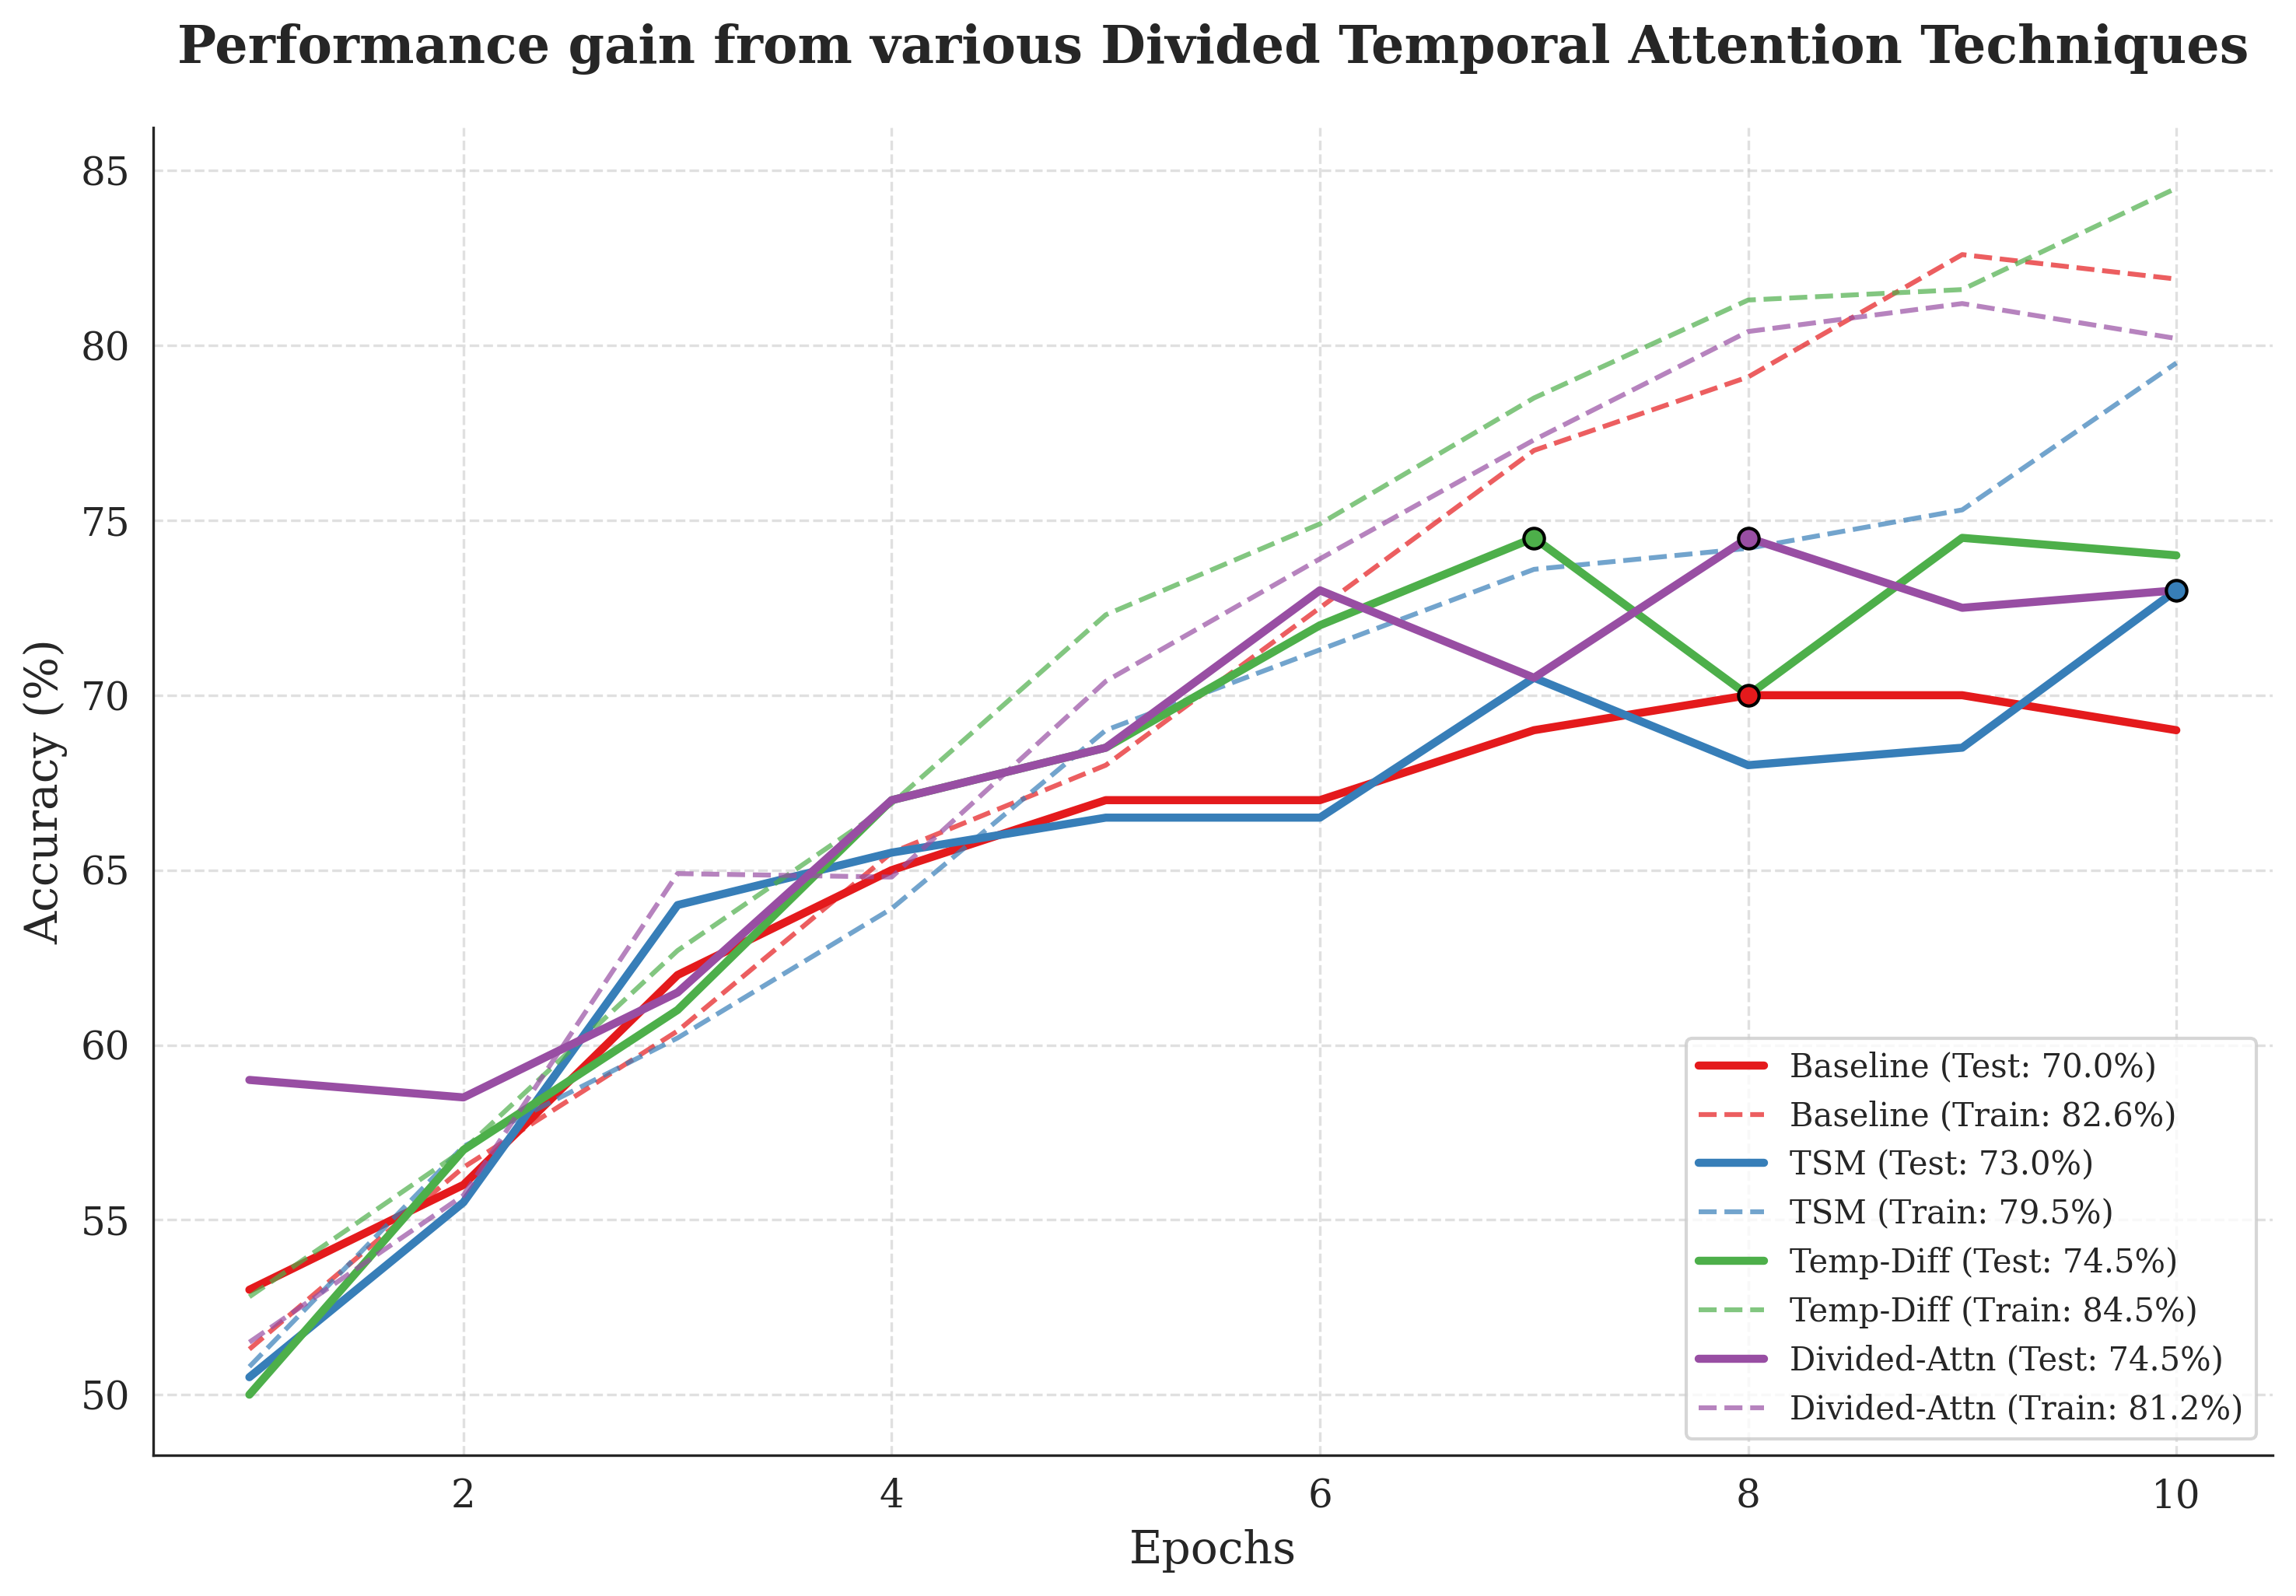

In [27]:
if results_log:
    plot_comparison(results_log)
else:
    print("Run the experiment cells first to populate results_log!")

From the above experiments, we observe that our model ACE.verify + Temp-Diff/Divided-Attn achieve the best performance boost of ~4% over the baseline, indicating that modeling temporal differences can be a crucial optimization for deepfake detection. The TSM model also shows improvement over the baseline (~ 3%). At the end, we finalized on the Temp-Diff model for integration into the ACE.verify pipeline, given its superior performance in both test and train accuracies.